# main

2026-02-08 14:05:53.572055: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-08 14:05:53.572124: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-08 14:05:53.639514: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-08 14:05:53.786924: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-08 14:05:54.911368: W tensorflow/compiler/tf2

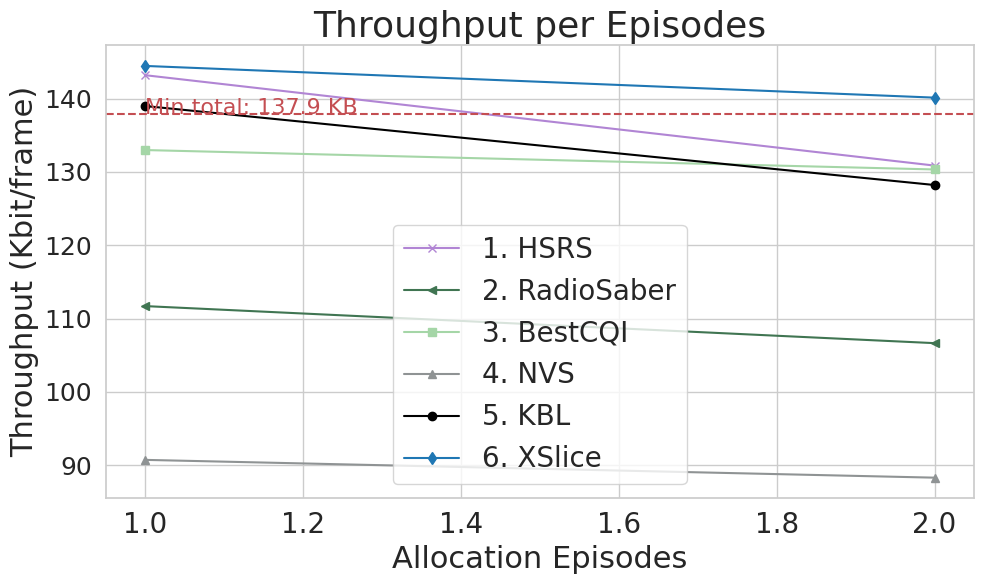

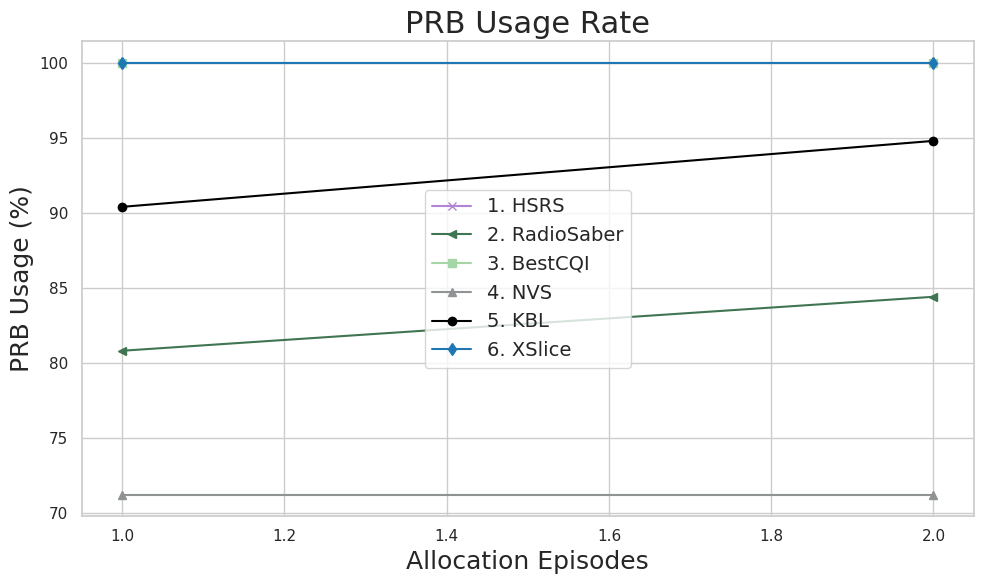

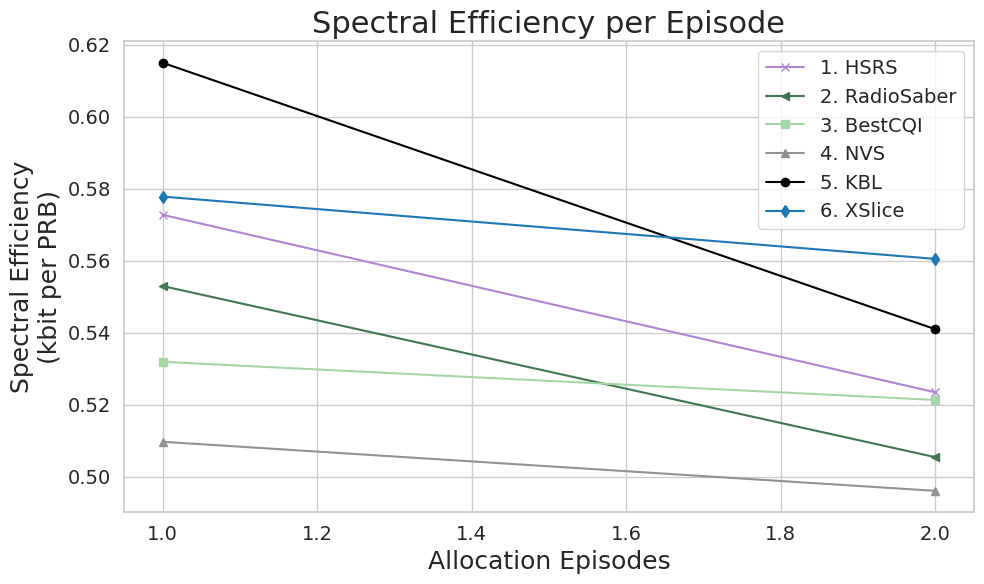

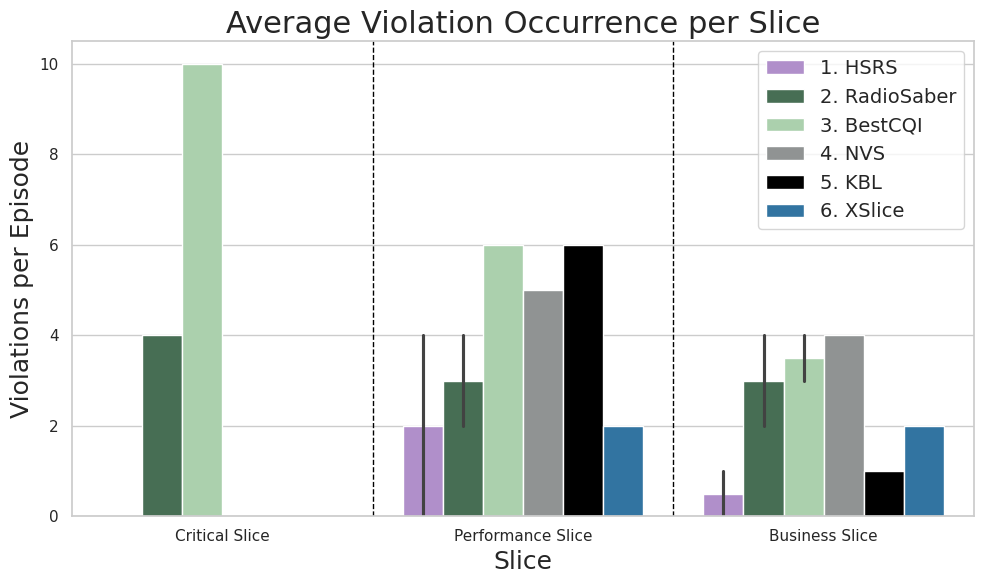

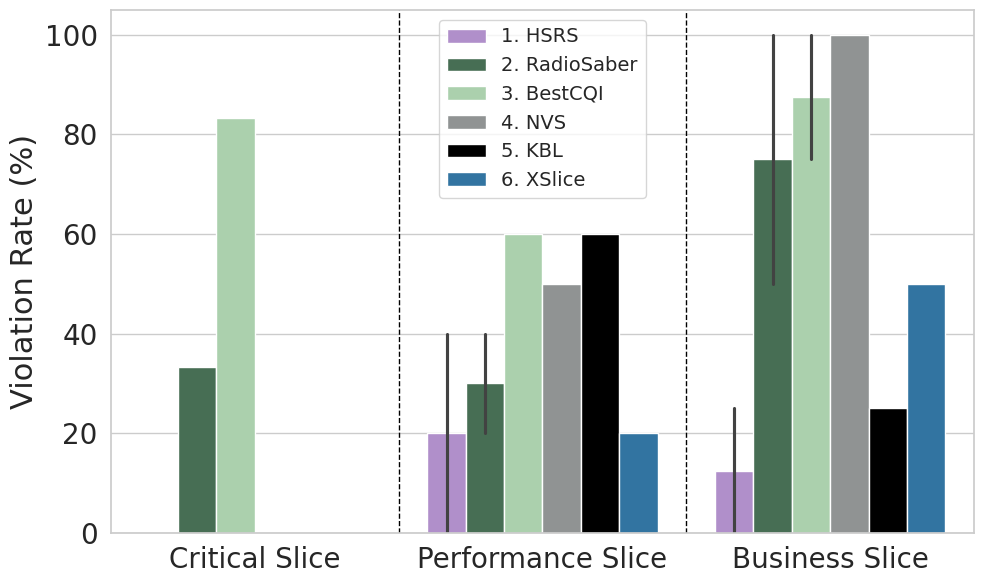

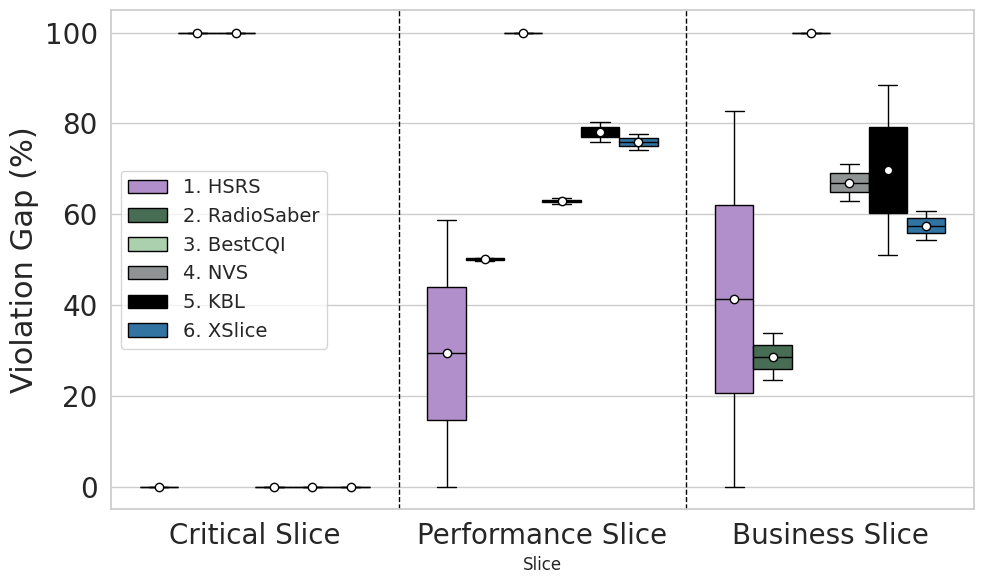

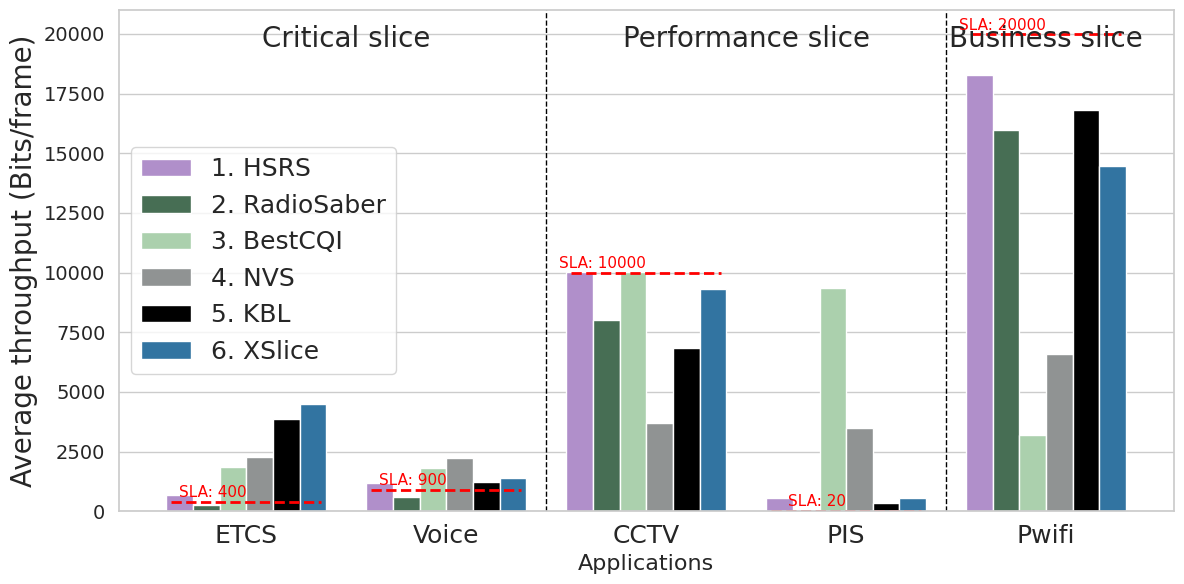

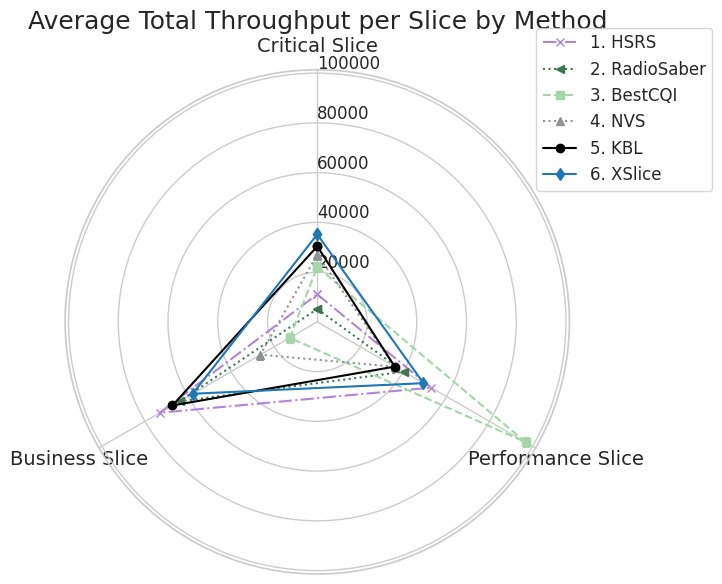

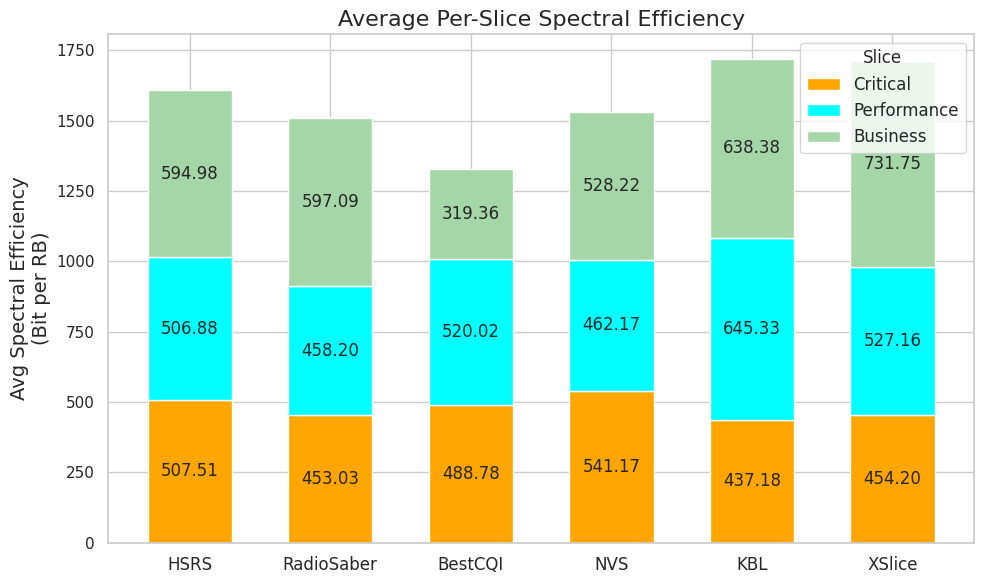

In [ ]:
import random
import numpy as np
import pandas as pd
import time 
from gurobipy import Model, GRB, quicksum
import math
from stable_baselines3.common.noise import NormalActionNoise
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Optional
import gym
from gym import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

import os
from functools import lru_cache
from collections import defaultdict

%load_ext autoreload
%autoreload 2

from ourfunctions import (
    generate_gamma,
    run_myheuristic_allocation,
    run_radiosaber_allocation,
    run_bestcqi_allocation,
    run_nvs_allocation,
    run_kbl_allocation,
    run_xslice_allocation,
    plot_all_results, print_final_results,
    get_sla, get_num_users_for_slice, get_slice_for_app,
    slice_spectral_efficiency, prbs_used_per_slice,
    APPKEY_LIST,
    K, T,
    min_required_datarate_KB
)
num_simulations = 2
TRAIN_XSLICE = True

hidden_size=128
n_steps=250
agent_gamma = 0.99
lam=0.25
clip_range=0.2
lr=0.005
batch_size=64
n_epochs=8
alpha=0.8
lambda_weight=0.5
weights = {1:120, 2:8, 3:2}
entropy_coef=0.02 
value_coef = 0.5
partial_train_steps= 2000
train_episode= 15
violation_threshold = 17
usage_threshold = 50

ACTION_NONE, ACTION_CRITIC, ACTION_PERF, ACTION_BUSI = 0, 1, 2, 3
N_ACTIONS = 4
OBS_DIM = 8
frames = []
#print(f"the minimum required {min_required_datarate_KB}")


class MultiSliceAllocationEnv(gym.Env):
    def __init__(self, input_gamma=None):
        super().__init__()
        self.input_gamma = input_gamma
        self.action_space = gym.spaces.Discrete(N_ACTIONS)
        self.observation_space = gym.spaces.Box(
            low=0.0, high=1e9, shape=(OBS_DIM,), dtype=np.float32
        )
        self.T = T
        self.K = K
        self.current_t = 0
        self.current_prb = 0
        self.slot_winners = set()
        self.gamma_critic = 0.0
        self.gamma_perf   = 0.0
        self.gamma_busi   = 0.0
        self.best_critic_delta   = 0.0
        self.gamma = {}
        self.allocation_so_far = {ak:0.0 for ak in APPKEY_LIST}
        self.mask_appkey = {ak:1 for ak in APPKEY_LIST}
        self.allocation_records = []
        self.best_critic_appkey = None
        self.best_perf_appkey   = None
        self.best_busi_appkey   = None
        self.best_critic_delta_appkey   = None
        self.reset()

    def reset(self):
        self.current_t = 0
        self.current_prb = 0
        self.gamma = self.input_gamma if self.input_gamma is not None else generate_gamma()

        # NEW: build a dict prb → list of (appk, thr)
        self.gamma_by_prb = defaultdict(list)
        for (u, a, s, p), thr in self.gamma.items():
            appk = (u, a, s)
            self.gamma_by_prb[p].append((appk, thr))

        # reset allocations, masks, records…
        for ak in APPKEY_LIST:
            self.allocation_so_far[ak] = 0.0
            self.mask_appkey[ak] = 1
        self.allocation_records.clear()
        return self._get_observation()
    def step(self, action):
        prb_idx = self.current_prb

        # 1) pick the pre-computed best app for this PRB & slice
        choice_app = [
            None,
            self.best_critic_appkey,
            self.best_perf_appkey,
            self.best_busi_appkey
        ][int(action)]

        reward = 0.0

          # 3) allocate throughput for only the selected app
        if choice_app is not None:
            thr = self.gamma.get((choice_app[0], choice_app[1], choice_app[2], prb_idx), 0.0)
            self.allocation_so_far[choice_app] += thr
            self.allocation_records.append(
                (self.current_t, prb_idx,
                choice_app[0], choice_app[1], choice_app[2],
                thr)
            )
           
            # 4) compute reward just for that single app
            
            sla = get_sla(choice_app[1])
            alloc = self.allocation_so_far[choice_app]
            if sla > 0:
                ratio = alloc / sla
                if ratio >= 1.0:
                    # mark SLA met
                    self.mask_appkey[choice_app] = 0
                reward += (thr / 1070.055) * weights[choice_app[2]]

            
        
        else:
            
          # 2) If agent chose NONE but there is still demand → penalize heavily
            

            unmet_prb = False
            for appk in (self.best_critic_appkey, self.best_perf_appkey, self.best_busi_appkey):
                if appk is not None and self.mask_appkey.get(appk, 0) == 1:
                    unmet_prb = True
                    break
            if unmet_prb:
                reward -= 500.0

        # 5) advance PRB / slot pointers
        self.current_prb += 1
        if self.current_prb >= self.K:
            self.current_prb = 0
            self.current_t  += 1
            

        done = (self.current_t >= self.T)
        obs  = self._get_observation()
        return obs, reward, done, {}

    def _update_best_slices(self):
        prb = self.current_prb
        entries = self.gamma_by_prb.get(prb, [])  # a tiny list

        # Precompute slack for critical apps once
        slack = {
            appk: max(0.0, get_sla(appk[1]) - self.allocation_so_far[appk])
            for appk in APPKEY_LIST if appk[2] == 1
        }
        self.best_critic_delta = 0.0
        self.gamma_critic = self.gamma_perf = self.gamma_busi = 0.0
        self.best_critic_appkey = self.best_perf_appkey = self.best_busi_appkey = None

        # Scan only the relevant entries for this PRB
        for appk, thr in entries:
            if self.mask_appkey.get(appk, 0) == 0:
                continue

            slice_id = appk[2]
            if slice_id == 1:
                need = slack.get(appk, 0.0)
                if need <= 0.0:
                    continue
                delta = min(need, thr)
                if delta > self.best_critic_delta:
                    self.best_critic_delta = delta
                    self.gamma_critic = thr
                    self.best_critic_appkey = appk

            elif slice_id == 2:
                if thr > self.gamma_perf:
                    self.gamma_perf = thr
                    self.best_perf_appkey = appk

            else:  # slice_id == 3
                if thr > self.gamma_busi:
                    self.gamma_busi = thr
                    self.best_busi_appkey = appk


    def _get_observation(self):
        self._update_best_slices()
        k = self.current_prb

        def filled_ratio(appk):
            if appk is None:
                return 1.0            # treat “no candidate” as fully fulfilled
            sla = get_sla(appk[1])
            alloc = self.allocation_so_far[appk]
            return min(alloc / sla, 1.0)

        fr_c = filled_ratio(self.best_critic_appkey)
        fr_p = filled_ratio(self.best_perf_appkey)
        fr_b = filled_ratio(self.best_busi_appkey)

        # compute γ_x as before (0 when appk is None)
        g_c = (self.gamma_critic / 1070.055) if self.best_critic_appkey else 0.0
        g_p = (self.gamma_perf   / 1070.055) if self.best_perf_appkey   else 0.0
        g_b = (self.gamma_busi   / 1070.055) if self.best_busi_appkey   else 0.0

        return np.array([
            float(self.current_t),
            float(k) / (self.K - 1),
            g_c, g_p, g_b,
            fr_c, fr_p, fr_b
        ], dtype=np.float32)


class RolloutBuffer:
    def __init__(self, buffer_size, obs_dim):
        self.buffer_size = buffer_size
        self.obs_dim = obs_dim
        self.observations = np.zeros((buffer_size, obs_dim), dtype=np.float32)
        # keep actions as a single int per step:
        self.actions      = np.zeros(buffer_size,         dtype=np.int32)
        self.rewards      = np.zeros(buffer_size,         dtype=np.float32)
        self.values       = np.zeros(buffer_size,         dtype=np.float32)
        self.dones        = np.zeros(buffer_size,         dtype=bool)
        self.logprobs     = np.zeros(buffer_size,         dtype=np.float32)
        self.advantages   = np.zeros(buffer_size,         dtype=np.float32)
        self.returns      = np.zeros(buffer_size,         dtype=np.float32)
        self.ptr = 0
        self.path_start_idx = 0

    def store(self, obs, action, reward, value, logprob, done):
        idx = self.ptr
        self.observations[idx] = obs
        self.actions[idx]      = action
        self.rewards[idx]      = reward
        self.values[idx]       = value
        self.logprobs[idx]     = logprob
        self.dones[idx]        = done
        self.ptr += 1

    def finish_path(self, last_value, gamma=0.99, lam=0.95):
        path_end = self.ptr
        adv = 0.0
        # compute GAE backwards
        for i in reversed(range(self.path_start_idx, path_end)):
            next_val = 0.0 if self.dones[i] else (
                last_value if i == path_end - 1 else self.values[i+1]
            )
            delta = self.rewards[i] + gamma * next_val - self.values[i]
            adv    = delta + gamma * lam * (0 if self.dones[i] else adv)
            self.advantages[i] = adv
        # compute returns
        for i in range(self.path_start_idx, path_end):
            self.returns[i] = self.values[i] + self.advantages[i]
        self.path_start_idx = self.ptr

    def get(self, batch_size, shuffle=True):
        idxs = np.arange(self.ptr)
        if shuffle:
            np.random.shuffle(idxs)
        for start in range(0, self.ptr, batch_size):
            end = start + batch_size
            batch = idxs[start:end]
            yield (
                self.observations[batch],
                self.actions[batch],      # now shape (batch_size,)
                self.advantages[batch],
                self.returns[batch],
                self.logprobs[batch]
            )

    def reset(self):
        self.ptr = 0
        self.path_start_idx = 0


class SharedNet(nn.Module):
    def __init__(self, obs_dim: int, hidden_size: int, n_actions: int):
        super().__init__()
        # Shared feature extractor: two hidden layers with ReLU
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(inplace=True)
        )
        # Policy head: raw logits
        self.policy_head = nn.Linear(hidden_size, n_actions)
        # Value head: raw scalar value
        self.value_head  = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor):
        h = self.shared(x)
        logits = self.policy_head(h)
        value  = self.value_head(h).squeeze(-1)
        return logits, value
    
class PPOAgent:
    def __init__(
        self,
        env,
        obs_dim,
        n_actions,
        lr=3e-4,
        gamma=0.99,
        lam=0.95,
        clip_eps=0.2,
        epochs=4,
        batch_size=64,
        hidden_size=128,
        entropy_coef=0.02,
        value_coef=0.5,
    ):
        self.env = env
        self.gamma = gamma
        self.lam   = lam
        self.clip_eps     = clip_eps
        self.ppo_epochs   = epochs
        self.batch_size   = batch_size
        self.entropy_coef = entropy_coef
        self.value_coef   = value_coef

        # Instantiate shared network
        self.net = SharedNet(obs_dim, hidden_size, n_actions)
        # Pre-allocated tensor for observation
        self.obs_tensor = torch.zeros(1, obs_dim)
        # Optimizer on all network parameters
        self.optimizer = optim.Adam(self.net.parameters(), lr=lr)

        # Set to evaluation mode for inference
        self.net.eval()

    def select_action(self, obs_np: np.ndarray):
        # Copy observation in-place
        self.obs_tensor[0].copy_(torch.from_numpy(obs_np))
        with torch.no_grad():
            logits, value = self.net(self.obs_tensor)
            dist = Categorical(logits=logits)
            action = dist.sample()
            logp   = dist.log_prob(action)
        return action.item(), logp.item(), value.item()

    def update(self, buffer):
        for _ in range(self.ppo_epochs):
            for obs_b, act_b, adv_b, ret_b, logp_b in buffer.get(self.batch_size):
                obs_t     = torch.from_numpy(obs_b)
                act_t     = torch.from_numpy(act_b)
                adv_t     = torch.from_numpy(adv_b)
                ret_t     = torch.from_numpy(ret_b)
                old_logp_t= torch.from_numpy(logp_b)

                # Single forward pass through shared net
                logits, value = self.net(obs_t)
                dist = Categorical(logits=logits)
                new_logp = dist.log_prob(act_t)
                entropy  = dist.entropy().mean()

                # Policy loss (clipped surrogate)
                ratio = torch.exp(new_logp - old_logp_t)
                clipped = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv_t
                policy_loss = -torch.min(ratio * adv_t, clipped).mean()

                # Value loss (MSE)
                value_loss = nn.functional.mse_loss(value, ret_t)

                # Total loss
                loss = policy_loss + self.value_coef * value_loss - self.entropy_coef * entropy

                # Optimization step
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
        buffer.reset()


def train_adss_agent_with_ppo(gamma, num_episodes, partial_train_steps, violation_threshold, usage_threshold):
    env = MultiSliceAllocationEnv(input_gamma=gamma)
    obs_dim   = env.observation_space.shape[0]
    n_actions = env.action_space.n

    agent = PPOAgent(
        env=env,
        obs_dim=obs_dim,
        n_actions=n_actions,
        lr=lr,
        gamma=agent_gamma,
        lam=lam,
        clip_eps=clip_range,
        epochs=4,
        batch_size=64,
        hidden_size=128,
        entropy_coef=entropy_coef,
        value_coef=value_coef,
    )
    buffer = RolloutBuffer(partial_train_steps, obs_dim)

    episodes, throughputs, prb_usages = [], [], []
    violations, rewards = [], []
    avg_gap_ratios, avg_prb_usages = [], []

    for ep in range(num_episodes):
        obs = env.reset()
        ep_reward = 0.0
        for t in range(partial_train_steps):
            action, logp, value = agent.select_action(obs)
            next_obs, rew, done, _ = env.step(action)
            buffer.store(obs, action, rew, value, logp, done)
            obs = next_obs

            if done:
                last_val = 0.0
                obs = env.reset()
            else:
                with torch.no_grad():
                    _, last_val = agent.net(torch.from_numpy(obs).float().unsqueeze(0))
                    last_val = last_val.item()


            if done or t == partial_train_steps - 1:
                buffer.finish_path(last_val, gamma=agent.gamma, lam=agent.lam)

        agent.update(buffer)

        # Evaluation
        test_gamma = gamma #generate_gamma(time_idx=ep)
        test_env   = MultiSliceAllocationEnv(input_gamma=test_gamma)
        obs_eval   = test_env.reset()
        done_eval  = False
        eval_reward = 0.0
        while not done_eval:
            action, _, _ = agent.select_action(obs_eval)
            obs_eval, rew_eval, done_eval, _ = test_env.step(action)
            eval_reward += rew_eval

        metrics, _ = compute_adss_allocation_metrics(test_env)
        total_thr  = metrics['Total_Throughput']
        prb_usage  = metrics['PRB_Usage(%)']
        total_viol = metrics['Total_Violations']

        gap_vals = list(metrics.get('Avg_Gap_Ratio_By_App', {}).values())
        prb_vals = list(metrics.get('Avg_PRB_Usage_By_App', {}).values())
        avg_gap_ratio = np.mean(gap_vals) if gap_vals else 0.0
        avg_prb_usage = np.mean(prb_vals) if prb_vals else 0.0

        episodes.append(ep+1)
        throughputs.append(total_thr)
        prb_usages.append(prb_usage)
        violations.append(total_viol)
        rewards.append(eval_reward)
        avg_gap_ratios.append(avg_gap_ratio)
        avg_prb_usages.append(avg_prb_usage)

        print(
            f"[Training Ep {ep+1}] => Thr={total_thr:.2f}KB, PRB_Usage={prb_usage:.1f}%, Viol={total_viol}, Reward={eval_reward:.2f}"
        )

        if total_viol <= violation_threshold and prb_usage >= usage_threshold :
            print(f"Stopping early at episode {ep+1}: violations <= {violation_threshold}, PRB_Usage={prb_usage:.1f}%")
            break
        #if total_viol == 0 and prb_usage == 100 :
         #   print(f"Stopping early at episode {ep+1}: violations <= {violation_threshold}, PRB_Usage={prb_usage:.1f}%")
         #   break

    training_results_df = pd.DataFrame({
        'Episode':             episodes,
        'Total_Throughput_KB': throughputs,
        'PRB_Usage_%':         prb_usages,
        'Total_Violations':    violations,
        'Episode_Reward':      rewards,
        'Avg_Gap_Ratio':       avg_gap_ratios,
        'Avg_PRB_Usage':       avg_prb_usages,
    })

    return agent, env, training_results_df

def train_until_threshold(
    gamma,
    num_episodes,
    partial_train_steps,
    violation_threshold=violation_threshold, usage_threshold=usage_threshold
):
    max_attempts = 50
    attempt = 0
    while attempt < max_attempts:
        attempt += 1
        print(f">>> Training attempt #{attempt}")
        agent, env, training_df = train_adss_agent_with_ppo(
            gamma=gamma,
            num_episodes=num_episodes,
            partial_train_steps=partial_train_steps,
            violation_threshold=violation_threshold, usage_threshold=usage_threshold
        )
        if len(training_df) < num_episodes:
            print(f"✅ Threshold reached on attempt #{attempt}")
            return agent, env, training_df
        print(f"❌ Threshold NOT reached (ran full {num_episodes} episodes). Retrying...")

    raise RuntimeError(f"Failed to reach threshold in {max_attempts} attempts")

def compute_adss_allocation_metrics(env):
    columns = ['Slot','PRB','User','App','Slice','Throughput']
    alloc_df = pd.DataFrame(env.allocation_records, columns=columns)
    slice_throughput_df = (
        alloc_df
          .groupby('Slice')['Throughput']
          .sum()
          .reset_index()
          .rename(columns={'Throughput': 'Total_Throughput'})
    )  
    #alloc_df.to_csv("allocation_df_adss_metrics.csv", index= True)
    total_thr = alloc_df['Throughput'].sum()
    avg_thr   = total_thr 
    total_prbs = K * T
    used_prbs  = len(alloc_df)  
    prb_usage_percent = (used_prbs / total_prbs) * 100 if total_prbs > 0 else 0

    # Summarize throughput per (User, App, Slice)
    app_thr_df = (
        alloc_df
        .groupby(['User','App','Slice'])['Throughput']
        .sum()
        .reset_index()
    )

    # -------------
    # 1) Violation & Gap Calculation 
    # -------------
    violation_counts_per_slice = {1: 0, 2: 0, 3: 0}
    violation_gap_per_slice    = {1: 0.0, 2: 0.0, 3: 0.0}
    for (i_, a_, s_) in APPKEY_LIST:
        # Grab how much throughput was allocated to this (user, app, slice)
        row_match = app_thr_df[
            (app_thr_df['User'] == i_) &
            (app_thr_df['App'] == a_) &
            (app_thr_df['Slice'] == s_)
        ]
        sla_needed = get_sla(a_)
        if len(row_match) > 0:
            allocated_thr = row_match.iloc[0]['Throughput']
            ratio = allocated_thr / sla_needed
            if ratio < 1 :
                #gap_ratio = 1-ratio 
                violation_counts_per_slice[s_] += 1
                violation_gap_per_slice[s_] += (1.0 - ratio)
            

        else:
            allocated_thr = 0.0
            
            violation_counts_per_slice[s_] += 1
            violation_gap_per_slice[s_] += 1.0


    # Final step: turn total gap into an average gap for each slice
    for s_ in [1, 2, 3]:
        if violation_counts_per_slice[s_] > 0:
            violation_gap_per_slice[s_] /= violation_counts_per_slice[s_]
        else:
            violation_gap_per_slice[s_] = 0.0

    total_violations = sum(violation_counts_per_slice.values())

    # gap ratio per App
    gap_ratios = {}
    for (i_, a_, s_) in APPKEY_LIST:
        mask = (
            (app_thr_df['User']  == i_) &
            (app_thr_df['App']   == a_) &
            (app_thr_df['Slice'] == s_)
        )
        allocated = app_thr_df.loc[mask, 'Throughput'].sum()
        sla_needed = get_sla(a_)
        ratio = ((sla_needed - allocated) / sla_needed) if sla_needed > 0 else 0.0
        ratio = max(0.0, ratio)
        gap_ratios.setdefault(a_, []).append(ratio)
    avg_gap_ratio_by_app = {app: np.mean(ratios) for app, ratios in gap_ratios.items()}

    # Average number of PRBs used per app
    prb_counts = alloc_df.groupby('App').size().to_dict()  # {app -> #rows}
    avg_prb_usage_by_app = {}
    for app_id, count in prb_counts.items():
        slice_id = get_slice_for_app(app_id)
        n_users = get_num_users_for_slice(slice_id)
        avg_prb_usage_by_app[app_id] = count / float(n_users) if n_users > 0 else 0

    # -------------
    # 3) Final Return
    # -------------
    return {
        'allocation_df': alloc_df,
        'Total_Throughput':       total_thr, 
        'Average_Throughput':     avg_thr,
        'PRB_Usage(%)':           prb_usage_percent,
        'Violation_Counts_Per_Slice': violation_counts_per_slice,
        'Violation_Gap_Per_Slice':    violation_gap_per_slice,
        'Total_Violations':       total_violations,
        'App_Throughput_DF':      app_thr_df,
        'Avg_Gap_Ratio_By_App':   avg_gap_ratio_by_app,
        'Avg_PRB_Usage_By_App':   avg_prb_usage_by_app,
        'Slice_Throughput_df': slice_throughput_df,
    }, app_thr_df


def run_simulation(num_simulations=3):
    simulation_results = []

    for sim in range(1, num_simulations + 1):
        gamma = generate_gamma(time_idx=sim + 1)

        # ── HSRS
        t0 = time.time()
        (alloc_df_my, total_thr_my, app_thr_df_my,
         app_episode_thr_my, viol_cnt_my,
         tot_viol_my, viol_gap_my, slice_thr_df_my) = run_myheuristic_allocation(gamma)
        time_taken_my = time.time() - t0
        slice_thr_my = slice_thr_df_my.set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_my = {f"HSRS_S{s}_Throughput": slice_thr_my.get(s, 0.0) for s in [1, 2, 3]}
        avg_thr_per_app_my = {
            f"HSRS_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_my[['App', 'Average_Throughput']].itertuples(index=False)
        }

        # ── RadioSaber
        t0 = time.time()
        (alloc_df_radiosaber, total_thr_radiosaber, app_thr_df_radiosaber,
         app_episode_thr_radiosaber, viol_cnt_radiosaber,
         tot_viol_radiosaber, viol_gap_radiosaber, slice_thr_df_radiosaber) = run_radiosaber_allocation(gamma)
        time_taken_radiosaber = time.time() - t0
        slice_thr_radiosaber = slice_thr_df_radiosaber.set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_radiosaber = {f"RadioSaber_S{s}_Throughput": slice_thr_radiosaber.get(s, 0.0) for s in [1, 2, 3]}
        avg_thr_per_app_radiosaber = {
            f"RadioSaber_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_radiosaber[['App', 'Average_Throughput']].itertuples(index=False)
        }

        # ── Best-CQI
        t0 = time.time()
        (alloc_df_cqi, total_thr_cqi, app_thr_df_cqi,
         app_episode_thr_cqi, viol_cnt_cqi,
         tot_viol_cqi, viol_gap_cqi, slice_thr_df_cqi) = run_bestcqi_allocation(gamma)
        time_taken_bestcqi = time.time() - t0
        slice_thr_cqi = slice_thr_df_cqi.set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_cqi = {f"BestCQI_S{s}_Throughput": slice_thr_cqi.get(s, 0.0) for s in [1, 2, 3]}
        avg_thr_per_app_cqi = {
            f"BestCQI_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_cqi[['App', 'Average_Throughput']].itertuples(index=False)
        }

        # ── NVS
        t0 = time.time()
        (alloc_df_nvs, total_thr_nvs, app_thr_df_nvs,
         app_episode_thr_nvs, viol_cnt_nvs,
         tot_viol_nvs, viol_gap_nvs, slice_thr_df_nvs) = run_nvs_allocation(gamma)
        time_taken_nvs = time.time() - t0
        slice_thr_nvs = slice_thr_df_nvs.set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_nvs = {f"NVS_S{s}_Throughput": slice_thr_nvs.get(s, 0.0) for s in [1, 2, 3]}
        avg_thr_per_app_nvs = {
            f"NVS_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_nvs[['App', 'Average_Throughput']].itertuples(index=False)
        }

        # ── KBL (KBRL)
        t0 = time.time()
        (alloc_df_kbl, total_thr_kbl, app_thr_df_kbl,
         app_episode_thr_kbl, viol_cnt_kbl,
         tot_viol_kbl, viol_gap_kbl, slice_thr_df_kbl) = run_kbl_allocation(gamma)
        time_taken_kbl = time.time() - t0
        slice_thr_kbl = slice_thr_df_kbl.set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_kbl = {f"KBL_S{s}_Throughput": slice_thr_kbl.get(s, 0.0) for s in [1, 2, 3]}
        avg_thr_per_app_kbl = {
            f"KBL_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_kbl[['App', 'Average_Throughput']].itertuples(index=False)
        }

        # ── XSlice
        t0 = time.time()
        (alloc_df_xs, total_thr_xs, app_thr_df_xs,
         app_episode_thr_xs, viol_cnt_xs,
         tot_viol_xs, viol_gap_xs, slice_thr_df_xs) = run_xslice_allocation(
            gamma, train_if_missing=TRAIN_XSLICE
        )
        time_taken_xs = time.time() - t0
        slice_thr_xs = slice_thr_df_xs.set_index('Slice')['Total_Throughput'].to_dict()
        slice_cols_xs = {f"XSlice_S{s}_Throughput": slice_thr_xs.get(s, 0.0) for s in [1, 2, 3]}
        avg_thr_per_app_xs = {
            f"XSlice_App_{int(app)}_Throughput": avg_thr
            for app, avg_thr in app_episode_thr_xs[['App', 'Average_Throughput']].itertuples(index=False)
        }

        # ── prepare metrics
        total_prbs = K * T
        usage_my = len(alloc_df_my) / total_prbs * 100
        usage_radiosaber = len(alloc_df_radiosaber) / total_prbs * 100
        usage_cqi = len(alloc_df_cqi) / total_prbs * 100
        usage_nvs = len(alloc_df_nvs) / total_prbs * 100
        usage_kbl = len(alloc_df_kbl) / total_prbs * 100
        usage_xs = len(alloc_df_xs) / total_prbs * 100

        # spectral efficiency
        se_my = slice_spectral_efficiency(alloc_df_my)
        se_radiosaber = slice_spectral_efficiency(alloc_df_radiosaber)
        se_cqi = slice_spectral_efficiency(alloc_df_cqi)
        se_nvs = slice_spectral_efficiency(alloc_df_nvs)
        se_kbl = slice_spectral_efficiency(alloc_df_kbl)
        se_xs = slice_spectral_efficiency(alloc_df_xs)

        slice_se_my = {f"HSRS_SE_S{s}": se_my.get(s, 0) for s in [1, 2, 3]}
        slice_se_radiosaber = {f"RadioSaber_SE_S{s}": se_radiosaber.get(s, 0) for s in [1, 2, 3]}
        slice_se_cqi = {f"BestCQI_SE_S{s}": se_cqi.get(s, 0) for s in [1, 2, 3]}
        slice_se_nvs = {f"NVS_SE_S{s}": se_nvs.get(s, 0) for s in [1, 2, 3]}
        slice_se_kbl = {f"KBL_SE_S{s}": se_kbl.get(s, 0) for s in [1, 2, 3]}
        slice_se_xs = {f"XSlice_SE_S{s}": se_xs.get(s, 0) for s in [1, 2, 3]}

        num_apps_slice = {
            s: len({(i, a) for (i, a, s_val, _) in gamma if s_val == s})
            for s in [1, 2, 3]
        }

        def make_rates(viol_cnt, prefix):
            return {f"{prefix}_Violation_Rate_S{s}":
                    (viol_cnt.get(s, 0) / num_apps_slice[s] * 100
                     if num_apps_slice[s] else 0)
                    for s in [1, 2, 3]}

        violation_rates = {
            **make_rates(viol_cnt_cqi, "BestCQI"),
            **make_rates(viol_cnt_nvs, "NVS"),
            **make_rates(viol_cnt_my, "HSRS"),
            **make_rates(viol_cnt_radiosaber, "RadioSaber"),
            **make_rates(viol_cnt_kbl, "KBL"),
            **make_rates(viol_cnt_xs, "XSlice"),
        }

        violation_gap_rates = {
            **{f"BestCQI_Violation_gap_S{s}": viol_gap_cqi.get(s, 0) for s in [1, 2, 3]},
            **{f"NVS_Violation_gap_S{s}": viol_gap_nvs.get(s, 0) for s in [1, 2, 3]},
            **{f"HSRS_Violation_gap_S{s}": viol_gap_my.get(s, 0) for s in [1, 2, 3]},
            **{f"RadioSaber_Violation_gap_S{s}": viol_gap_radiosaber.get(s, 0) for s in [1, 2, 3]},
            **{f"KBL_Violation_gap_S{s}": viol_gap_kbl.get(s, 0) for s in [1, 2, 3]},
            **{f"XSlice_Violation_gap_S{s}": viol_gap_xs.get(s, 0) for s in [1, 2, 3]},
        }

        simulation_results.append({
            'Simulation': sim,

            # --- HSRS ---
            'HSRS_Total_Throughput': total_thr_my * 0.001,
            'HSRS_PRB_Usage (%)': usage_my,
            'HSRS_Time_Taken': time_taken_my,
            'HSRS_Violations_S1': viol_cnt_my.get(1, 0),
            'HSRS_Violations_S2': viol_cnt_my.get(2, 0),
            'HSRS_Violations_S3': viol_cnt_my.get(3, 0),
            'HSRS_Total_Violations': tot_viol_my,

            # --- RadioSaber ---
            'RadioSaber_Total_Throughput': total_thr_radiosaber * 0.001,
            'RadioSaber_PRB_Usage (%)': usage_radiosaber,
            'RadioSaber_Time_Taken': time_taken_radiosaber,
            'RadioSaber_Violations_S1': viol_cnt_radiosaber.get(1, 0),
            'RadioSaber_Violations_S2': viol_cnt_radiosaber.get(2, 0),
            'RadioSaber_Violations_S3': viol_cnt_radiosaber.get(3, 0),
            'RadioSaber_Total_Violations': tot_viol_radiosaber,

            # --- Best-CQI ---
            'BestCQI_Total_Throughput': total_thr_cqi * 0.001,
            'BestCQI_PRB_Usage (%)': usage_cqi,
            'BestCQI_Time_Taken': time_taken_bestcqi,
            'BestCQI_Violations_S1': viol_cnt_cqi.get(1, 0),
            'BestCQI_Violations_S2': viol_cnt_cqi.get(2, 0),
            'BestCQI_Violations_S3': viol_cnt_cqi.get(3, 0),
            'BestCQI_Total_Violations': tot_viol_cqi,

            # --- NVS ---
            'NVS_Total_Throughput': total_thr_nvs * 0.001,
            'NVS_PRB_Usage (%)': usage_nvs,
            'NVS_Time_Taken': time_taken_nvs,
            'NVS_Violations_S1': viol_cnt_nvs.get(1, 0),
            'NVS_Violations_S2': viol_cnt_nvs.get(2, 0),
            'NVS_Violations_S3': viol_cnt_nvs.get(3, 0),
            'NVS_Total_Violations': tot_viol_nvs,

            # --- KBL ---
            'KBL_Total_Throughput': total_thr_kbl * 0.001,
            'KBL_PRB_Usage (%)': usage_kbl,
            'KBL_Time_Taken': time_taken_kbl,
            'KBL_Violations_S1': viol_cnt_kbl.get(1, 0),
            'KBL_Violations_S2': viol_cnt_kbl.get(2, 0),
            'KBL_Violations_S3': viol_cnt_kbl.get(3, 0),
            'KBL_Total_Violations': tot_viol_kbl,

            # --- XSlice ---
            'XSlice_Total_Throughput': total_thr_xs * 0.001,
            'XSlice_PRB_Usage (%)': usage_xs,
            'XSlice_Time_Taken': time_taken_xs,
            'XSlice_Violations_S1': viol_cnt_xs.get(1, 0),
            'XSlice_Violations_S2': viol_cnt_xs.get(2, 0),
            'XSlice_Violations_S3': viol_cnt_xs.get(3, 0),
            'XSlice_Total_Violations': tot_viol_xs,

            # --- shared stats ---
            'Min_required_datarate_KB': min_required_datarate_KB,
            **violation_rates,
            **violation_gap_rates,

            **slice_cols_my,
            **slice_cols_radiosaber,
            **slice_cols_cqi,
            **slice_cols_nvs,
            **slice_cols_kbl,
            **slice_cols_xs,

            # spectral efficiencies
            **slice_se_my,
            **slice_se_radiosaber,
            **slice_se_cqi,
            **slice_se_nvs,
            **slice_se_kbl,
            **slice_se_xs,

            # --- per-app throughput ---
            **avg_thr_per_app_my,
            **avg_thr_per_app_radiosaber,
            **avg_thr_per_app_cqi,
            **avg_thr_per_app_nvs,
            **avg_thr_per_app_kbl,
            **avg_thr_per_app_xs
        })

    results_df = pd.DataFrame(simulation_results)
    return results_df


results_df = run_simulation(num_simulations=num_simulations)
results_df.to_csv("results_df_xslice.csv", index=False)

plot_all_results(results_df)


## plots

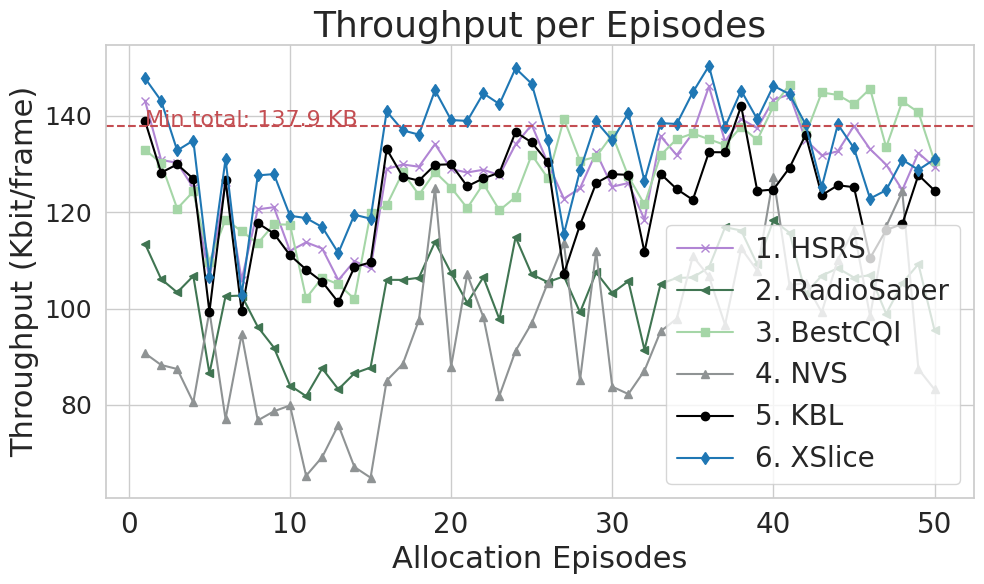

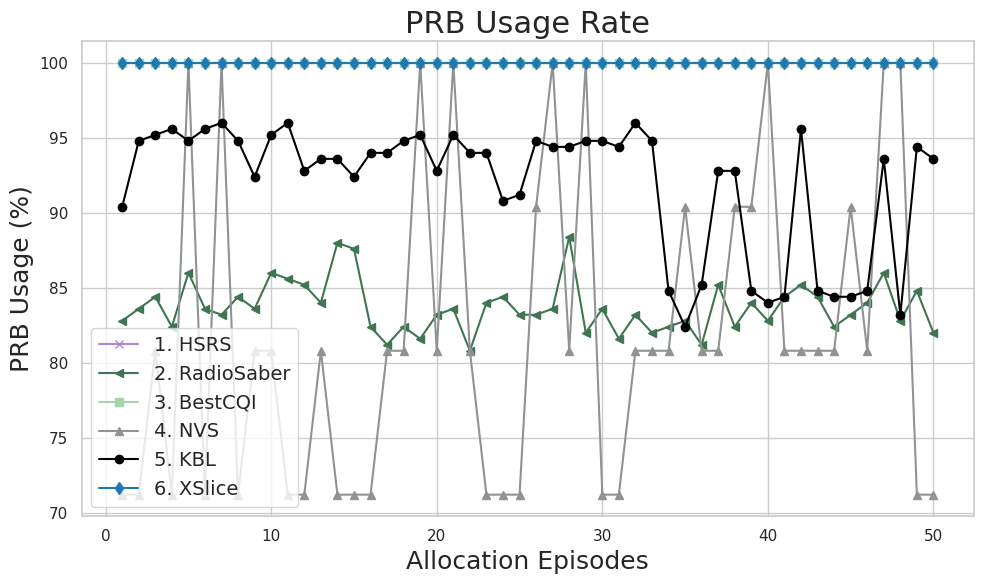

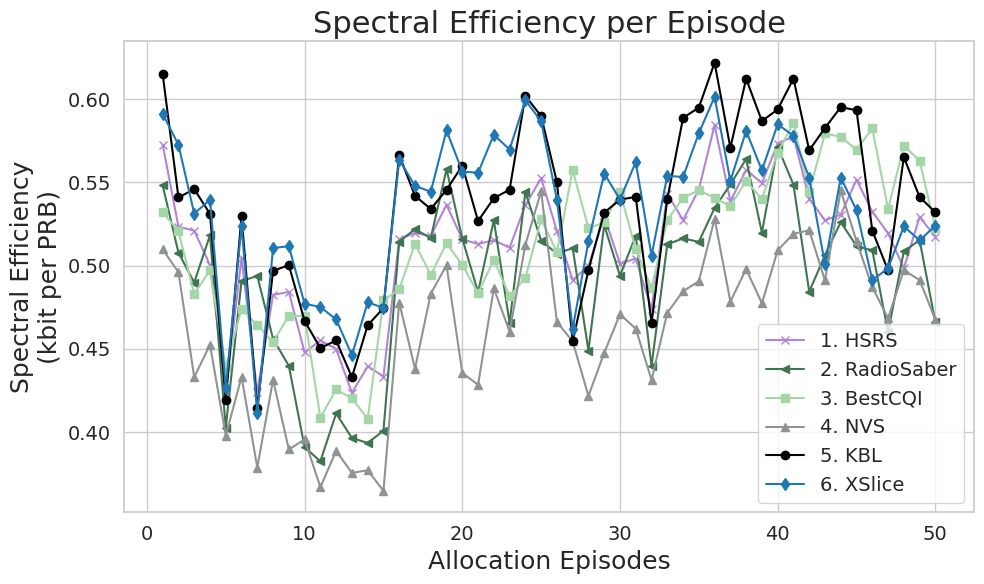

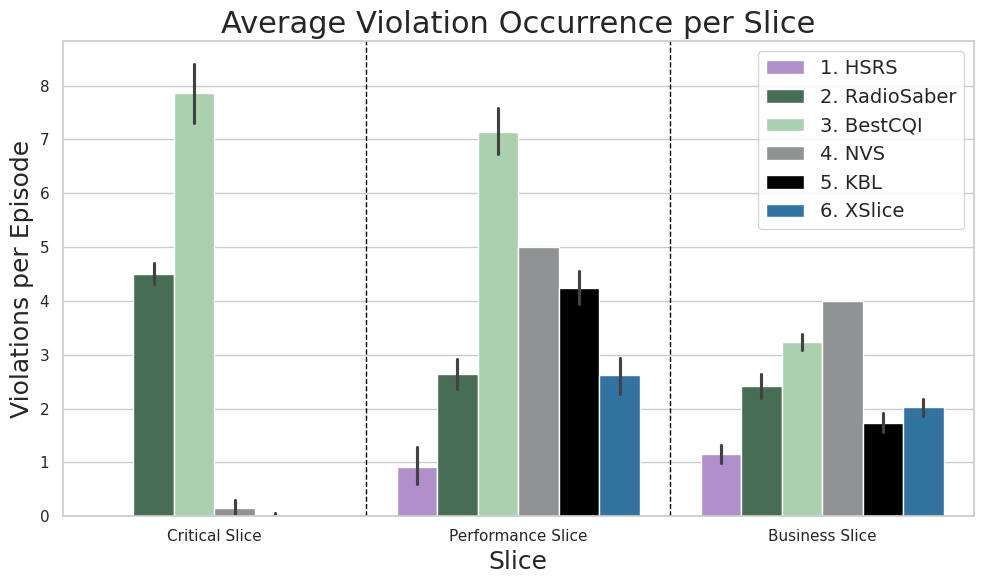

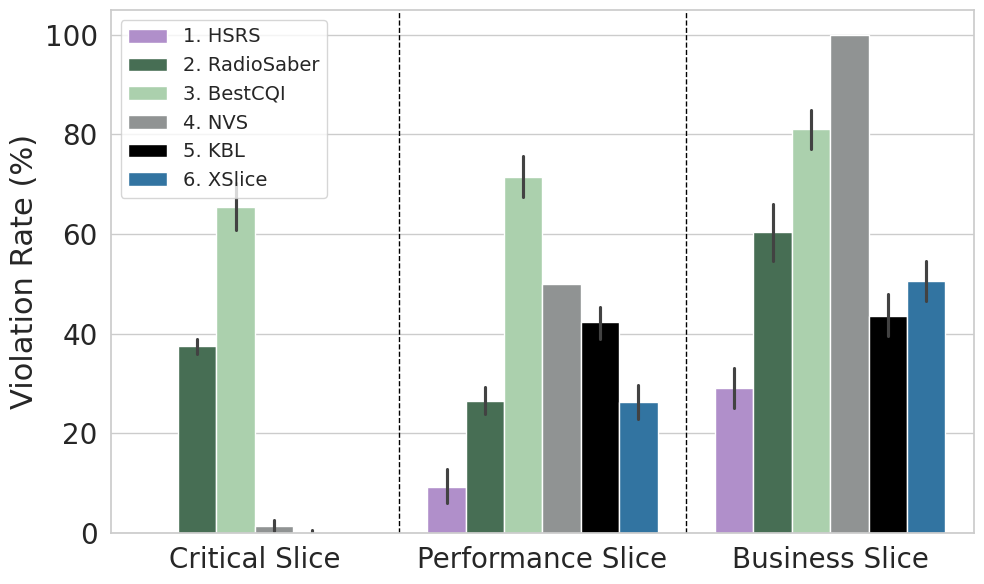

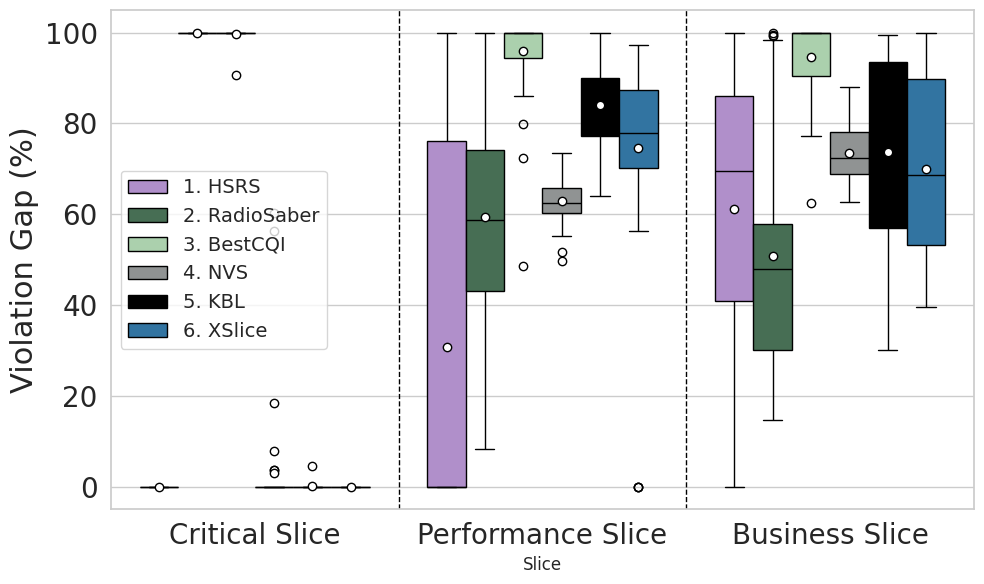

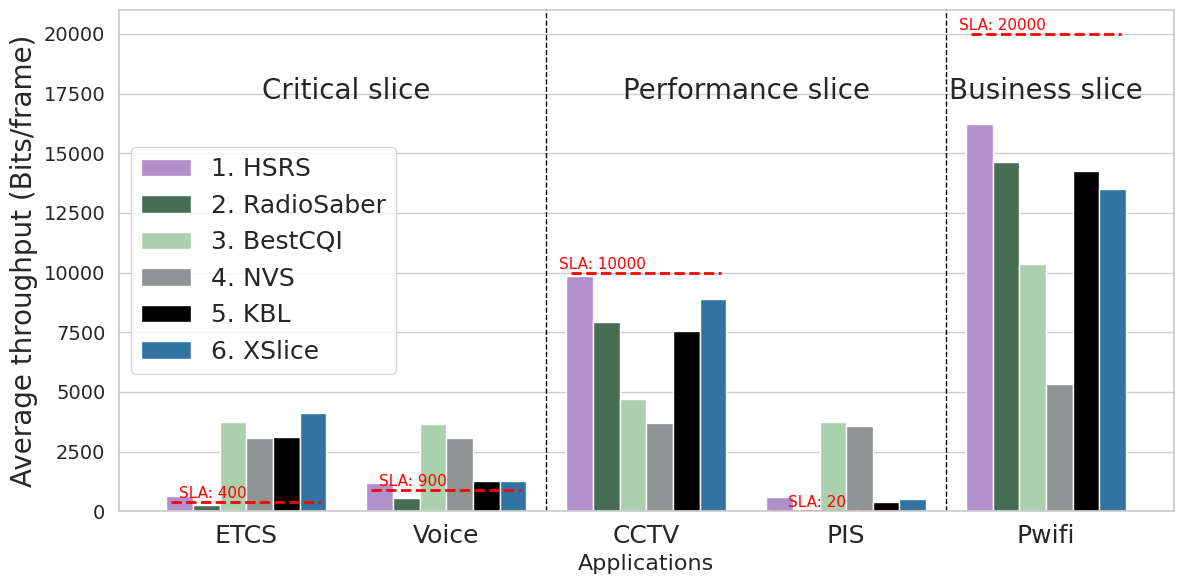

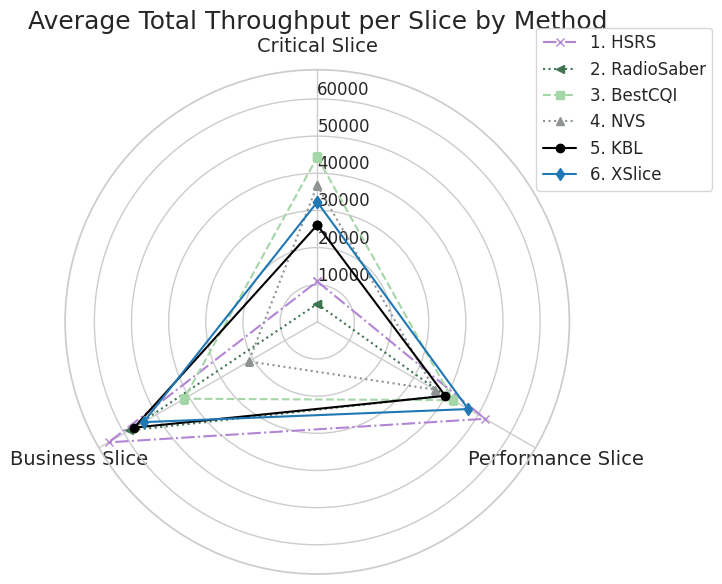

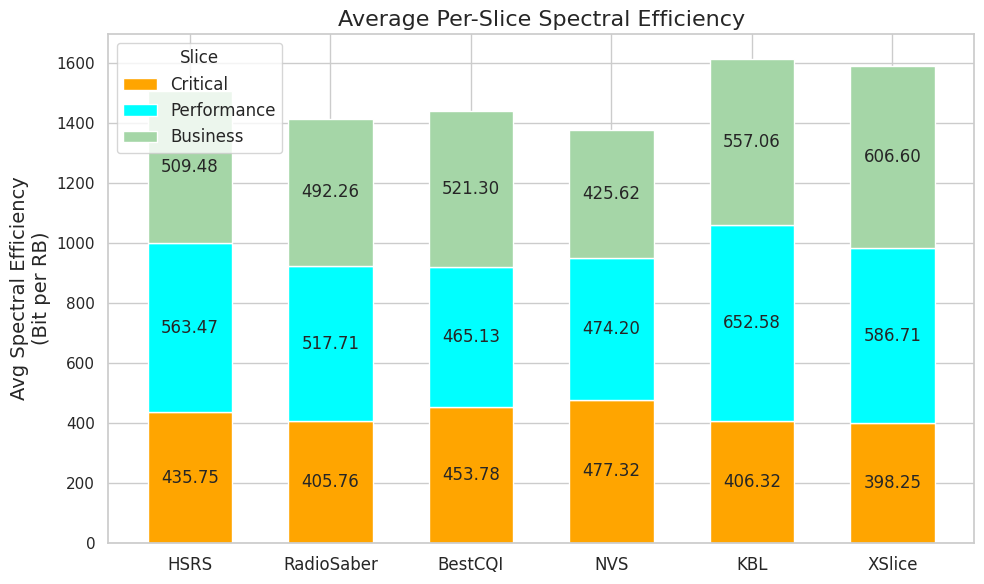

In [15]:
import pandas as pd
from ourfunctions import plot_all_results

results_df = pd.read_csv("results_df_xslice.csv")
plot_all_results(results_df)


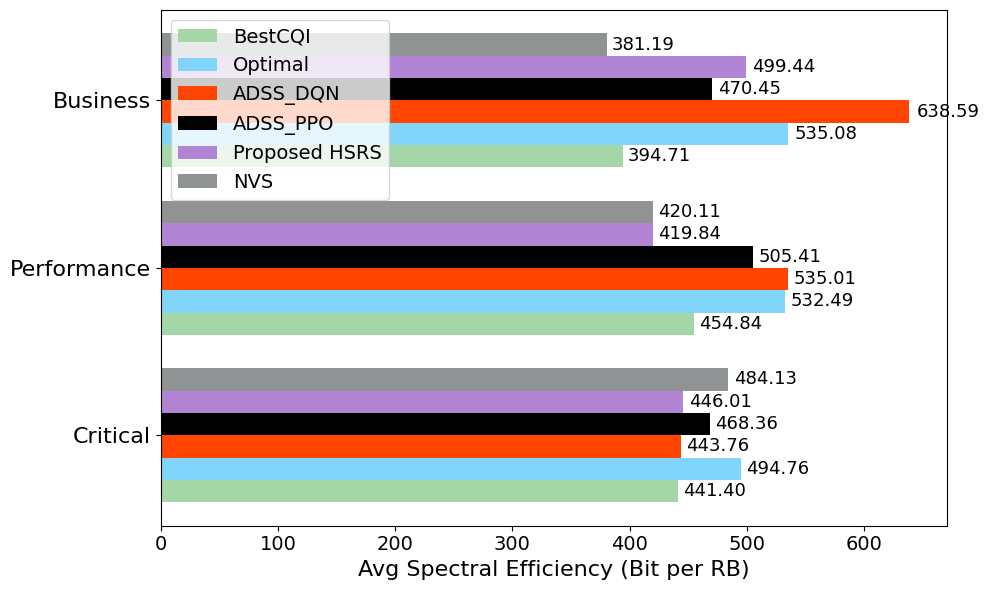

In [27]:
import random
import numpy as np
import pandas as pd
import time 
from gurobipy import Model, GRB, quicksum
import math
import matplotlib.pyplot as plt
import seaborn as sns

def single_plot_results(results_df):
    """
    Draws three views of per‐slice spectral efficiency:
      1) Original stacked bar (per‐method)
      2) Horizontal grouped bars (per‐method)
      3) Horizontal grouped bars (per‐slice)
    """
    # --- Configuration ---
    methods_info = [
        ('BestCQI',       'BestCQI'),
        ('Optimal ILP',   'Optimal_ILP'),
        ('ADSS_DQN',          'ADSS_DQN'),
        ('ADSS_PPO',          'ADSS_PPO'),
        ('Proposed HSRS', 'HSRS'),
        
        ('NVS',           'NVS'),
    ]
    method_names = [name for name, _ in methods_info]
    prefixes     = [prefix for _, prefix in methods_info]

    slice_labels = ['Critical', 'Performance', 'Business']
    slice_ids    = [1, 2, 3]

    # Color maps
    slice_colors = {
        'Critical':    'orange',
        'Performance': 'cyan',
        'Business':    '#A5D6A7',
    }
    method_colors = {
        'Optimal ILP':   '#81D4FA',
        'BestCQI':       '#A5D6A7',
        'NVS':           '#8f9394',
        'Proposed HSRS': '#b185d4',
        'ADSS_DQN':          'orangered',
        'ADSS_PPO':          'black',
    }

    # --- Build data array: methods × slices ---
    data = np.array([
        [ results_df[f'{prefix}_SE_S{s}'].mean() for s in slice_ids ]
        for prefix in prefixes
    ])


    ##### 2) Horizontal grouped bar by method #####
    n_methods, n_slices = data.shape
    y = np.arange(n_methods)
    bar_h = 0.8 / n_slices



    ##### 3) Horizontal grouped bar by slice #####
    data_t = data.T  # slices × methods
    ys = np.arange(len(slice_labels))
    bar_h2 = 0.8 / n_methods

    plt.figure(figsize=(10, 6))
    for j, m in enumerate(method_names):
        vals = data_t[:, j]
        display_label = "Optimal" if m == "Optimal ILP" else m  # display change for optimal 
        bars = plt.barh(
            ys + (j - (n_methods-1)/2)*bar_h2,
            vals,
            height=bar_h2,
            label=display_label,
            color=method_colors[m]  # still keyed by "Optimal ILP"
        )
        for bar in bars:
            w = bar.get_width()
            yc = bar.get_y() + bar.get_height()/2
            plt.text(w + 0.01*w, yc, f'{w:.2f}', va='center', ha='left', fontsize=13)

    plt.yticks(ys, slice_labels,fontsize=16)
    plt.xticks(fontsize=14)
    plt.xlabel('Avg Spectral Efficiency (Bit per RB)',fontsize=16)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.show()

results_df = pd.read_csv("results_df.csv")
single_plot_results(results_df)